In [43]:
# Olist巴西电商数据分析项目
## 作者 ：陈奕帆
## 数据时间范围：2016-09~2018-10
## 分析目标：订单健康度、用户价值、销售趋势、物流效率、地域差异

In [44]:
import pandas as pd
import matplotlib.pyplot as plt  

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [45]:
orders = pd.read_csv("C:/Users/28098/Desktop/olist/archive/olist_orders_dataset.csv")

In [46]:
# 只保留已交付的有效订单
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

print("原始订单总数：", len(orders))
print("有效成交订单数：", len(orders_delivered))

原始订单总数： 99441
有效成交订单数： 96478


In [47]:
# 计算有效订单占比
total_orders = len(orders)
valid_orders = len(orders_delivered)
valid_rate = valid_orders / total_orders * 100

print(f"原始订单总数：{total_orders} 单")
print(f"有效成交订单数：{valid_orders} 单")
print(f"✅ 有效订单占比：{valid_rate:.2f}%")
print(f"❌ 未交付/取消订单占比：{100 - valid_rate:.2f}%")

原始订单总数：99441 单
有效成交订单数：96478 单
✅ 有效订单占比：97.02%
❌ 未交付/取消订单占比：2.98%


In [48]:
# 把时间列都转成标准时间格式
time_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in time_cols:
    orders_delivered[col] = pd.to_datetime(orders_delivered[col])

In [49]:
# 先将订单时间列转为 datetime 类型
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

In [50]:
# 提取下单小时（0-23）
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour

# 按小时统计订单量
hourly_sales = orders.groupby("purchase_hour").size()

# 打印小时销量Top3
print("⏰ 下单量最高的3个小时：")
print(hourly_sales.sort_values(ascending=False).head(3))

⏰ 下单量最高的3个小时：
purchase_hour
16    6675
11    6578
14    6569
dtype: int64


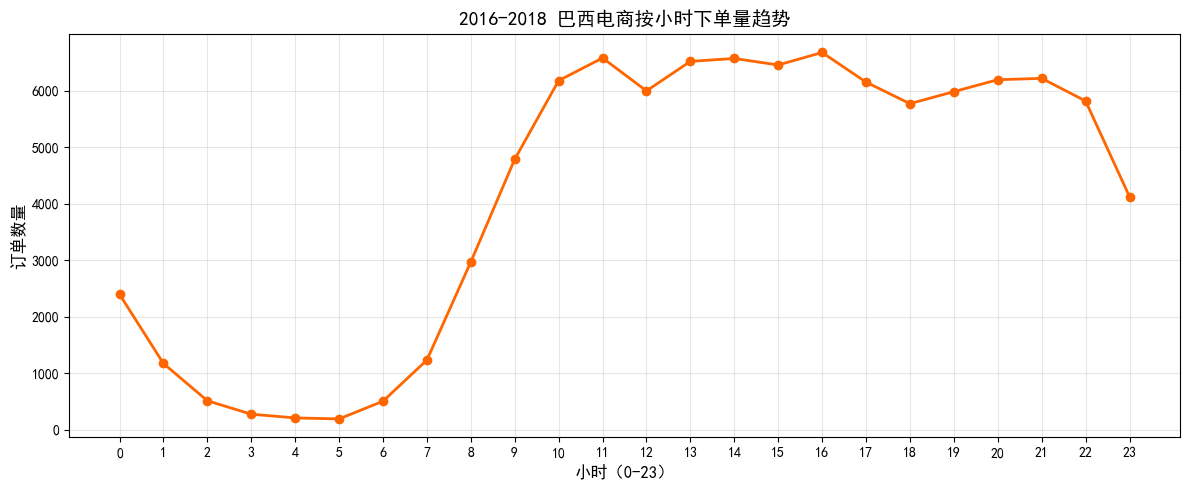

⏰ 下单量最高的3个小时：
purchase_hour
16    6675
11    6578
14    6569
dtype: int64


In [51]:
# 1. 提取下单小时（0-23）
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour

# 2. 按小时统计订单量
hourly_sales = orders.groupby("purchase_hour").size()

# 3. 绘制小时销量趋势图
plt.figure(figsize=(12, 5))
hourly_sales.plot(kind="line", marker="o", color="#ff6600", linewidth=2)
plt.title("2016-2018 巴西电商按小时下单量趋势", fontsize=14)
plt.xlabel("小时（0-23）", fontsize=12)
plt.ylabel("订单数量", fontsize=12)
plt.xticks(range(0, 24))  # 让x轴完整显示0-23点
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. 打印小时销量Top3
print("⏰ 下单量最高的3个小时：")
print(hourly_sales.sort_values(ascending=False).head(3))

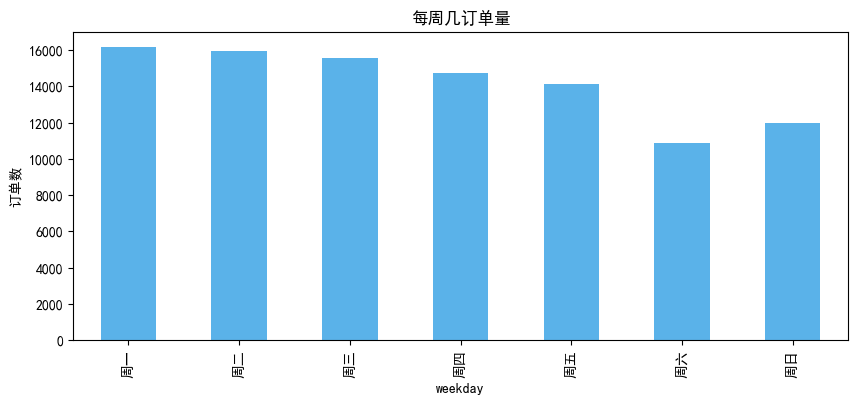

一周订单量排行：
weekday
周一    16196
周二    15963
周三    15552
周四    14761
周五    14122
周日    11960
周六    10887
dtype: int64


In [52]:
# 提取星期几（0=周一，6=周日）
orders["weekday"] = orders["order_purchase_timestamp"].dt.weekday

# 统计每周几的订单量
weekday_order = orders.groupby("weekday").size()

# 换成中文名字
name_map = {0:"周一",1:"周二",2:"周三",3:"周四",4:"周五",5:"周六",6:"周日"}
weekday_order.index = weekday_order.index.map(name_map)

# 画图
plt.figure(figsize=(10,4))
weekday_order.plot(kind="bar", color="#5ab2e9")
plt.title("每周几订单量")
plt.ylabel("订单数")
plt.show()

print("一周订单量排行：")
print(weekday_order.sort_values(ascending=False))

In [53]:
# 支付等待时间（小时）
orders_delivered["payment_wait_hours"] = (
    orders_delivered["order_approved_at"] 
    - orders_delivered["order_purchase_timestamp"]
).dt.total_seconds() / 3600

# 总物流时长（小时）
orders_delivered["delivery_total_hours"] = (
    orders_delivered["order_delivered_customer_date"] 
    - orders_delivered["order_purchase_timestamp"]
).dt.total_seconds() / 3600

# 实际 vs 预计 送达差距（小时）
orders_delivered["delivery_diff_hours"] = (
    orders_delivered["order_delivered_customer_date"] 
    - orders_delivered["order_estimated_delivery_date"]
).dt.total_seconds() / 3600

# 结果
orders_delivered[["payment_wait_hours", 
                  "delivery_total_hours", 
                  "delivery_diff_hours"]].head()

,payment_wait_hours,delivery_total_hours,delivery_diff_hours
0,0.178333,202.477778,-170.579722
1,30.713889,330.768889,-128.537500
2,0.276111,225.461111,-413.891944
3,0.298056,317.010000,-311.521667
4,1.030556,68.973056,-221.716111


===== 支付等待时长（小时)=====
count    96464.000000
mean        10.276767
std         20.535419
min          0.000000
25%          0.215278
50%          0.343333
75%         14.514583
max        741.443611
Name: payment_wait_hours, dtype: float64

===== 总物流时长（小时）=====
count    96470.000000
mean       301.397210
std        229.107753
min         12.801944
25%        162.388889
50%        245.219444
75%        377.284375
max       5031.086667
Name: delivery_total_hours, dtype: float64

===== 实际 - 预计送达差距（小时）=====
count    96470.000000
mean      -268.275017
std        244.424494
min      -3504.386944
25%       -389.857569
50%       -286.754444
75%       -153.355556
max       4535.401944
Name: delivery_diff_hours, dtype: float64


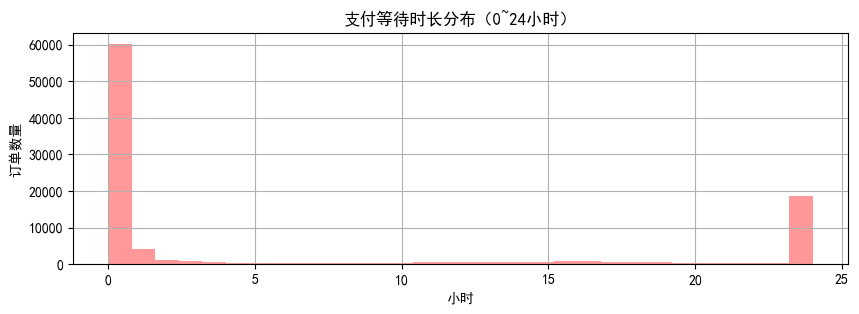

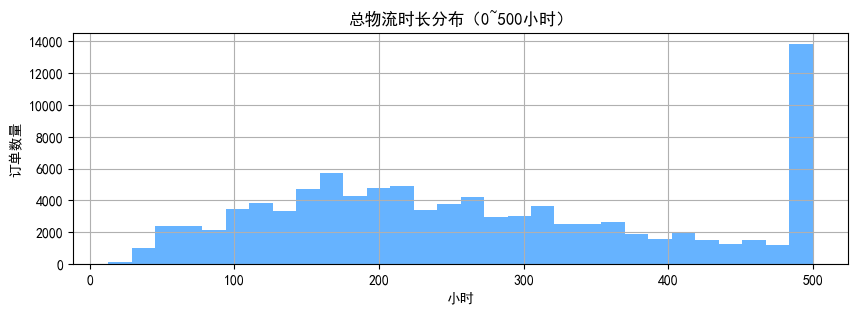

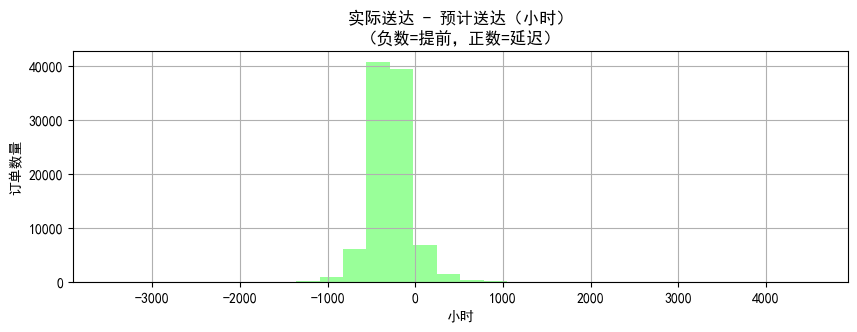

In [54]:

# ======================= 履约时效分析=======================
import matplotlib.pyplot as plt

# 1. 查看关键指标统计结果
print("===== 支付等待时长（小时)=====")
print(orders_delivered["payment_wait_hours"].describe())

print("\n===== 总物流时长（小时）=====")
print(orders_delivered["delivery_total_hours"].describe())

print("\n===== 实际 - 预计送达差距（小时）=====")
print(orders_delivered["delivery_diff_hours"].describe())

# 2. 画图1：支付时长分布
plt.figure(figsize=(10,3))
orders_delivered["payment_wait_hours"].clip(0, 24).hist(bins=30, color="#ff9999")
plt.title("支付等待时长分布（0~24小时）")
plt.xlabel("小时")
plt.ylabel("订单数量")
plt.show()

# 3. 画图2：总物流时长分布
plt.figure(figsize=(10,3))
orders_delivered["delivery_total_hours"].clip(0, 500).hist(bins=30, color="#66b3ff")
plt.title("总物流时长分布（0~500小时）")
plt.xlabel("小时")
plt.ylabel("订单数量")
plt.show()

# 4. 画图3：送达准时性分布
plt.figure(figsize=(10,3))
orders_delivered["delivery_diff_hours"].hist(bins=30, color="#99ff99")
plt.title("实际送达 - 预计送达（小时）\n（负数=提前，正数=延迟）")
plt.xlabel("小时")
plt.ylabel("订单数量")
plt.show()

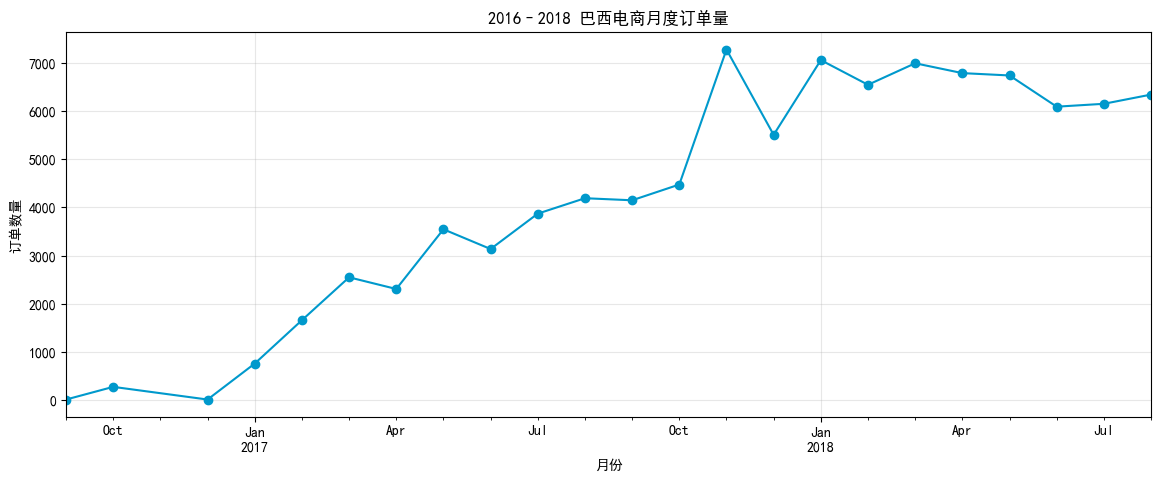

In [55]:
# 画月度订单量趋势图
orders_delivered["month"] = orders_delivered["order_purchase_timestamp"].dt.to_period("M")
monthly_orders = orders_delivered.groupby("month").size()

plt.figure(figsize=(14, 5))
monthly_orders.plot(kind="line", marker="o", color="#0099cc")
plt.title("2016–2018 巴西电商月度订单量")
plt.xlabel("月份")
plt.ylabel("订单数量")
plt.grid(alpha=0.3)
plt.show()

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# 订单表 (总表)
orders = pd.read_csv("C:/Users/28098/Desktop/olist/archive/olist_orders_dataset.csv")

# 支付表
payments = pd.read_csv("C:/Users/28098/Desktop/olist/archive/olist_order_payments_dataset.csv")

# 先看一眼payment长什么样
print("支付表前5行：")
print(payments.head())

支付表前5行：
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


In [57]:
# 用order_id作为连接键，把orders和payments合并
# 用left_join保留所有订单
order_payment = pd.merge(orders, payments, on='order_id', how='left')

# 查看合并后的表前5行，确认合并成功
print("合并后的表前5行：")
print(order_payment.head())

合并后的表前5行：
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00        

支付方式订单数量分布：
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

支付方式订单金额分布：
payment_type
boleto          2869361.27
credit_card    12542084.19
debit_card       217989.79
not_defined           0.00
voucher          379436.87
Name: payment_value, dtype: float64


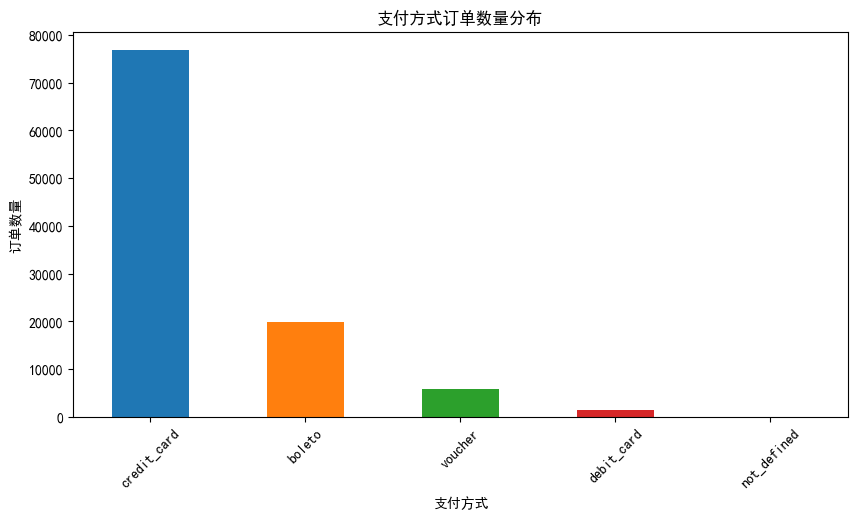

In [58]:
# 统计每种支付方式的订单数量
payment_type_count = order_payment['payment_type'].value_counts()

# 统计每种支付方式的订单金额总和
payment_type_amount = order_payment.groupby('payment_type')['payment_value'].sum()

# 打印结果
print("支付方式订单数量分布：")
print(payment_type_count)
print("\n支付方式订单金额分布：")
print(payment_type_amount)

# 可视化（可选，直观展示）
plt.figure(figsize=(10, 5))
payment_type_count.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('支付方式订单数量分布')
plt.xlabel('支付方式')
plt.ylabel('订单数量')
plt.xticks(rotation=45)
plt.show()

信用卡分期次数分布：
payment_installments
0.0         2
1.0     25455
2.0     12413
3.0     10461
4.0      7098
5.0      5239
6.0      3920
7.0      1626
8.0      4268
9.0       644
10.0     5328
11.0       23
12.0      133
13.0       16
14.0       15
15.0       74
16.0        5
17.0        8
18.0       27
20.0       17
21.0        3
22.0        1
23.0        1
24.0       18
Name: count, dtype: int64

分期次数为0（断供）的订单数量：2


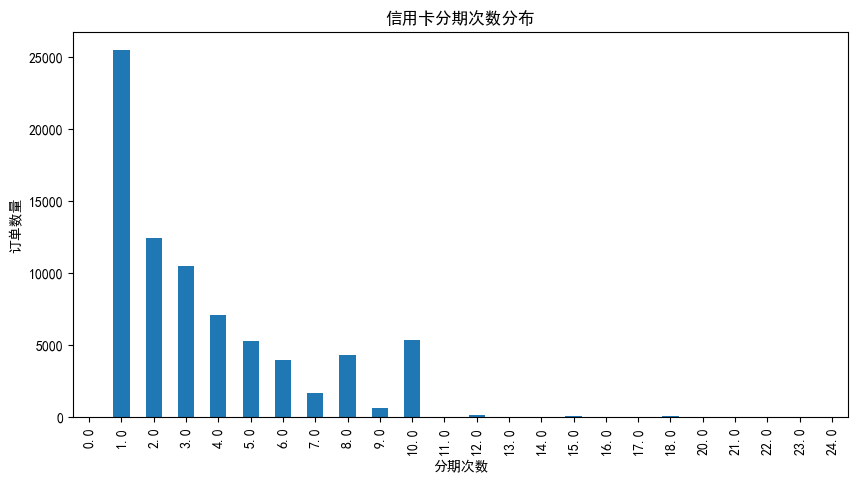

In [59]:

# 筛选出使用信用卡的订单（只有信用卡支持分期）
credit_card_data = order_payment[order_payment['payment_type'] == 'credit_card']

# 统计分期次数分布
installment_count = credit_card_data['payment_installments'].value_counts().sort_index()

# 查看有没有分期次数为0的情况（代表断供/未完成支付）
zero_installment = credit_card_data[credit_card_data['payment_installments'] == 0]

# 打印结果
print("信用卡分期次数分布：")
print(installment_count)
print(f"\n分期次数为0（断供）的订单数量：{len(zero_installment)}")

# 可视化分期次数
plt.figure(figsize=(10, 5))
installment_count.plot(kind='bar', color='#1f77b4')
plt.title('信用卡分期次数分布')
plt.xlabel('分期次数')
plt.ylabel('订单数量')
plt.show()

💳 各支付方式订单统计：
              order_count   avg_value
payment_type                         
credit_card         74304  162.243516
boleto              19191  144.334979
voucher              3679   62.445511
debit_card           1485  140.256474


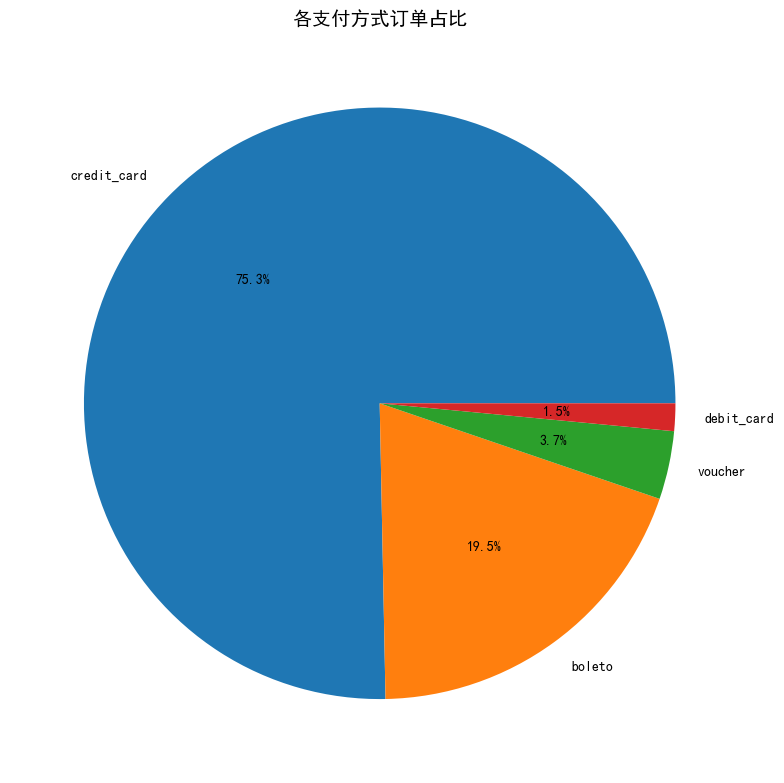

In [60]:
# 1. 读取支付表
order_payments = pd.read_csv("C:/Users/28098/Desktop/olist/archive/olist_order_payments_dataset.csv")

# 2. 合并订单和支付数据
order_payment = pd.merge(
    orders_delivered,
    order_payments[["order_id", "payment_type", "payment_value"]],
    on="order_id",
    how="left"
)

# 3. 统计各支付方式的订单数和平均金额
payment_stats = order_payment.groupby("payment_type").agg(
    order_count=("order_id", "nunique"),
    avg_value=("payment_value", "mean")
).sort_values("order_count", ascending=False)

print("💳 各支付方式订单统计：")
print(payment_stats)

# 4. 画支付方式占比饼图
plt.figure(figsize=(8,8))
payment_stats["order_count"].plot(kind="pie", autopct="%1.1f%%", labels=payment_stats.index)
plt.title("各支付方式订单占比", fontsize=14)
plt.tight_layout()
plt.show()

In [61]:
print(order_payment.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_wait_hours', 'delivery_total_hours', 'delivery_diff_hours',
       'month', 'payment_type', 'payment_value'],
      dtype='str')


In [62]:
# 1. 先重新合并
order_payment = pd.merge(
    orders_delivered,
    order_payments[['order_id', 'payment_type', 'payment_value', 'payment_installments']],
    on='order_id',
    how='left'
)

In [63]:
# 2. 筛选信用卡数据
credit_card_data = order_payment[order_payment['payment_type'] == 'credit_card']

# 3. 计算不同分期次数的客单价
# 现在可以正常使用 payment_installments 了
avg_installment_value = credit_card_data.groupby('payment_installments')['payment_value'].mean().sort_index()

print("\n不同分期次数客单价:")
print(avg_installment_value)


不同分期次数客单价:
payment_installments
0.0      94.315000
1.0      95.600013
2.0     126.590616
3.0     142.000005
4.0     163.640599
5.0     182.303774
6.0     208.540694
7.0     185.952131
8.0     306.286649
9.0     197.971197
10.0    410.537456
11.0    125.597273
12.0    324.408672
13.0    151.826667
14.0    169.360000
15.0    431.128194
16.0    292.694000
17.0    174.522857
18.0    486.483333
20.0    641.784375
21.0    243.700000
22.0    228.710000
23.0    236.480000
24.0    610.048889
Name: payment_value, dtype: float64


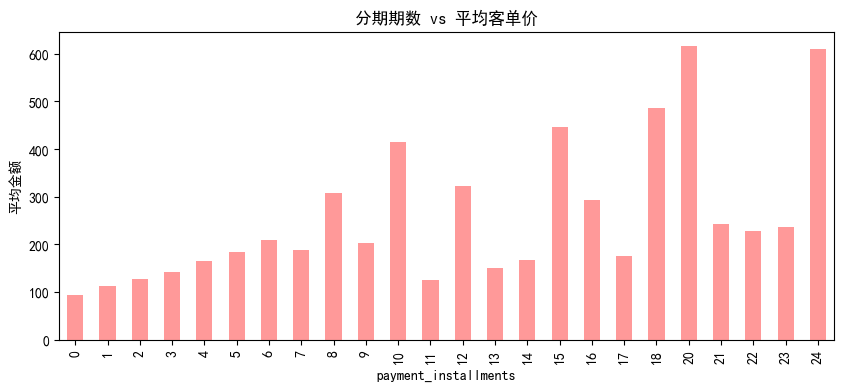

In [64]:
# 按分期数分组，算平均支付金额
installment_price = payments.groupby('payment_installments')['payment_value'].mean()

# 画图
installment_price.plot(kind='bar', figsize=(10,4), color='#ff9999')
plt.title('分期期数 vs 平均客单价')
plt.ylabel('平均金额')
plt.show()

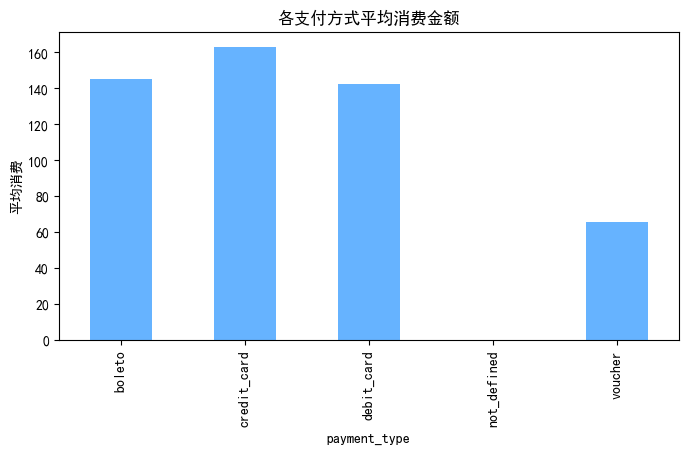

In [65]:
# 按支付方式算平均消费
pay_type_avg = payments.groupby('payment_type')['payment_value'].mean()

pay_type_avg.plot(kind='bar', figsize=(8,4), color='#66b3ff')
plt.title('各支付方式平均消费金额')
plt.ylabel('平均消费')
plt.show()

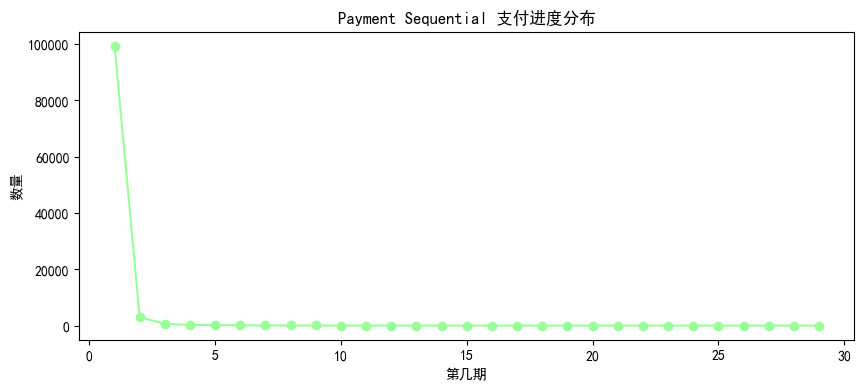

In [66]:
# 统计用户进行到第几期支付
seq_count = payments['payment_sequential'].value_counts().sort_index()

seq_count.plot(kind='line', marker='o', figsize=(10,4), color='#99ff99')
plt.title('Payment Sequential 支付进度分布')
plt.xlabel('第几期')
plt.ylabel('数量')
plt.show()

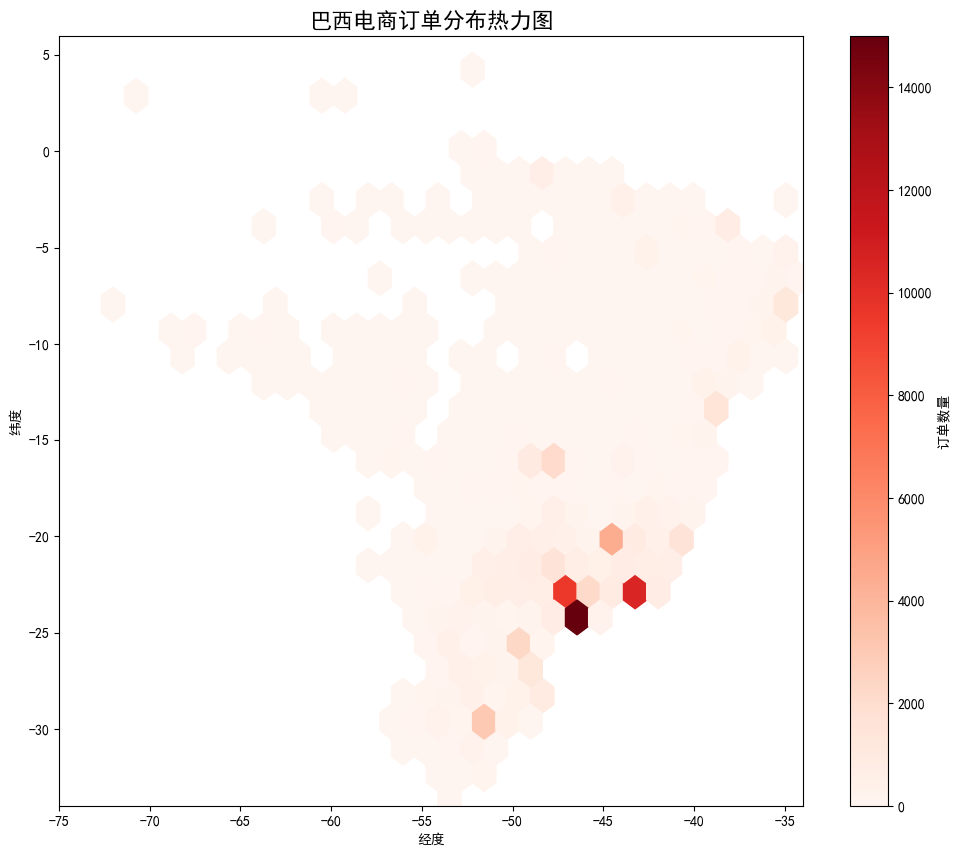

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 1. 读取数据
cust = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_customers_dataset.csv")
geo = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_geolocation_dataset.csv")

# 2. 合并经纬度（关键步骤，保证坐标准确）
geo_mean = geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]].mean()
cust_geo = cust.merge(geo_mean, left_on="customer_zip_code_prefix", right_index=True)

# 3. 画密度热力图（不用 seaborn/contextily）
plt.figure(figsize=(12, 10))
hb = plt.hexbin(
    data=cust_geo,
    x="geolocation_lng",
    y="geolocation_lat",
    gridsize=50,
    cmap="Reds",
    mincnt=1,
    vmin=0,vmax=15000
)
plt.colorbar(hb, label="订单数量")
plt.title("巴西电商订单分布热力图", fontsize=16)
plt.xlabel("经度")
plt.ylabel("纬度")
plt.xlim(-75, -34)  # 锁定巴西范围
plt.ylim(-34, 6)
plt.show()

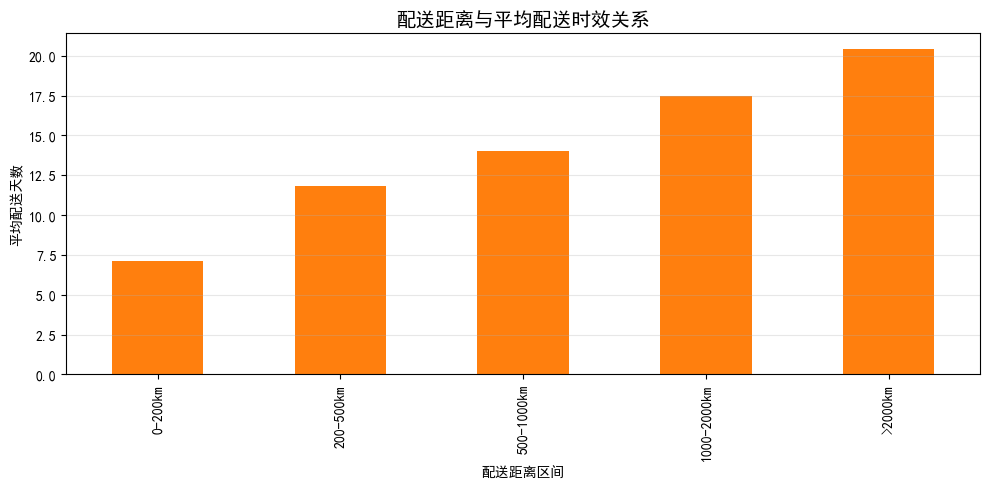

=== 配送距离 → 平均配送天数 ===
dist_group
0-200km         7.1
200-500km      11.8
500-1000km     14.0
1000-2000km    17.5
>2000km        20.4
Name: delivery_days, dtype: float64


In [68]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt

# 解决中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 读取所有需要的表
cust = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_customers_dataset.csv")
seller = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_sellers_dataset.csv")
geo = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_geolocation_dataset.csv")
orders = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_orders_dataset.csv")
items = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_order_items_dataset.csv")

# 2. 取唯一经纬度（提速）
geo_mean = geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]].mean()

# 3. 买家经纬度
cust_geo = cust.merge(geo_mean, left_on="customer_zip_code_prefix", right_index=True, how="inner")

# 4. 卖家经纬度
seller_geo = seller.merge(geo_mean, left_on="seller_zip_code_prefix", right_index=True, how="inner")

# 5. 订单 + 商品（要用卖家ID）
order_seller = orders.merge(items[["order_id","seller_id"]], on="order_id", how="inner")

# 6. 合并买家、卖家经纬度
df = order_seller.merge(cust_geo[["customer_id","geolocation_lat","geolocation_lng"]], on="customer_id", how="inner")
df = df.merge(seller_geo[["seller_id","geolocation_lat","geolocation_lng"]], on="seller_id", how="inner", suffixes=("_cust","_sell"))

# 7. 计算配送距离（公里）
def calc_distance(row):
    try:
        return geodesic((row.geolocation_lat_cust, row.geolocation_lng_cust),
                        (row.geolocation_lat_sell, row.geolocation_lng_sell)).km
    except:
        return np.nan

df["delivery_distance_km"] = df.apply(calc_distance, axis=1)

# 8. 计算实际配送天数
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.total_seconds() / (3600*24)

# 9. 合并时效
df = df.merge(orders[["order_id","delivery_days"]], on="order_id", how="inner")

# 10. 清洗异常值
df = df.dropna(subset=["delivery_distance_km","delivery_days"])
df = df[(df["delivery_days"] > 0) & (df["delivery_days"] < 60)]
df = df[df["delivery_distance_km"] < 3000]

# 11. 分组看：距离越远，配送天数越长
dist_bins = [0,200,500,1000,2000,3000]
dist_labels = ["0-200km","200-500km","500-1000km","1000-2000km",">2000km"]
df["dist_group"] = pd.cut(df["delivery_distance_km"], bins=dist_bins, labels=dist_labels)

result = df.groupby("dist_group")["delivery_days"].mean().round(1)

# 12. 画图
plt.figure(figsize=(10,5))
result.plot(kind="bar", color="#ff7f0e")
plt.title("配送距离与平均配送时效关系", fontsize=14)
plt.ylabel("平均配送天数")
plt.xlabel("配送距离区间")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 13. 打印结果
print("=== 配送距离 → 平均配送天数 ===")
print(result)

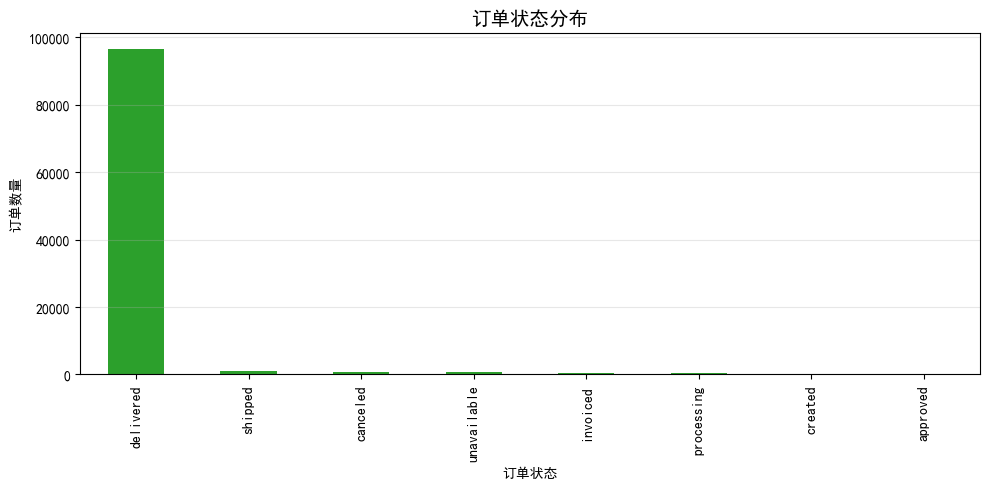

=== 订单状态占比 ===
order_status
delivered      97.02%
shipped         1.11%
canceled        0.63%
unavailable     0.61%
invoiced        0.32%
processing       0.3%
created         0.01%
approved         0.0%
Name: count, dtype: str


In [69]:
import pandas as pd
import matplotlib.pyplot as plt

# 解决中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取订单表
orders = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_orders_dataset.csv")

# 1. 统计各订单状态数量
order_status_counts = orders["order_status"].value_counts()

# 2. 画图
plt.figure(figsize=(10,5))
order_status_counts.plot(kind="bar", color="#2ca02c")
plt.title("订单状态分布", fontsize=14)
plt.ylabel("订单数量")
plt.xlabel("订单状态")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 打印占比（写报告用）
print("=== 订单状态占比 ===")
print((order_status_counts / order_status_counts.sum() * 100).round(2).astype(str) + "%")

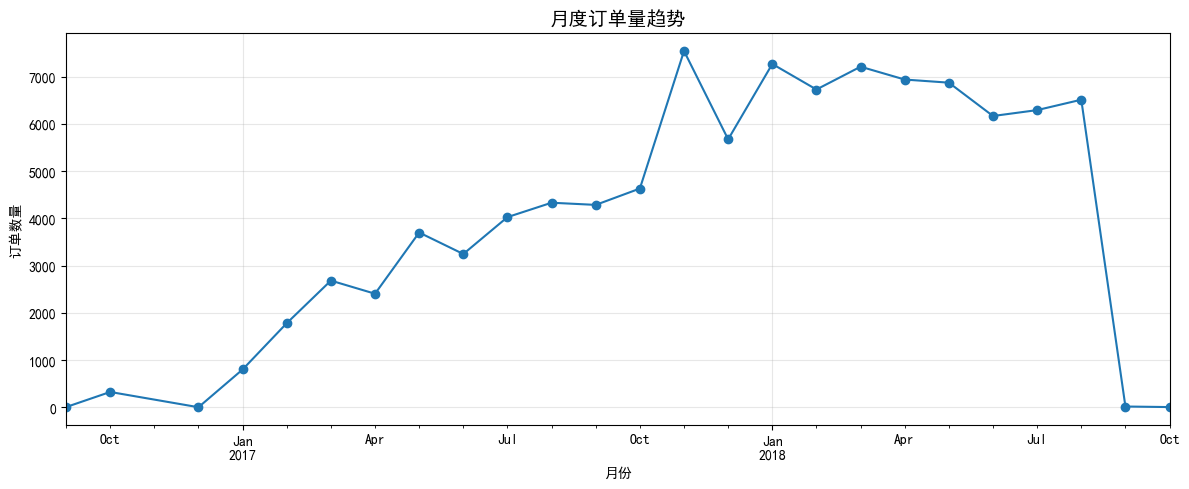

=== 平均配送时效 ===
全部订单平均配送天数：12.6 天


In [70]:
# 转换时间格式
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

# 1. 按月份统计订单量
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
monthly_orders = orders.groupby("order_month").size()

# 2. 画图
plt.figure(figsize=(12,5))
monthly_orders.plot(kind="line", marker="o", color="#1f77b4")
plt.title("月度订单量趋势", fontsize=14)
plt.ylabel("订单数量")
plt.xlabel("月份")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 计算配送时效（之前算过，这里复用）
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.total_seconds() / (3600*24)

print("=== 平均配送时效 ===")
print(f"全部订单平均配送天数：{orders['delivery_days'].mean().round(1)} 天")

=== 单笔订单商品数分布 ===
order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
10        8
12        5
Name: count, dtype: int64


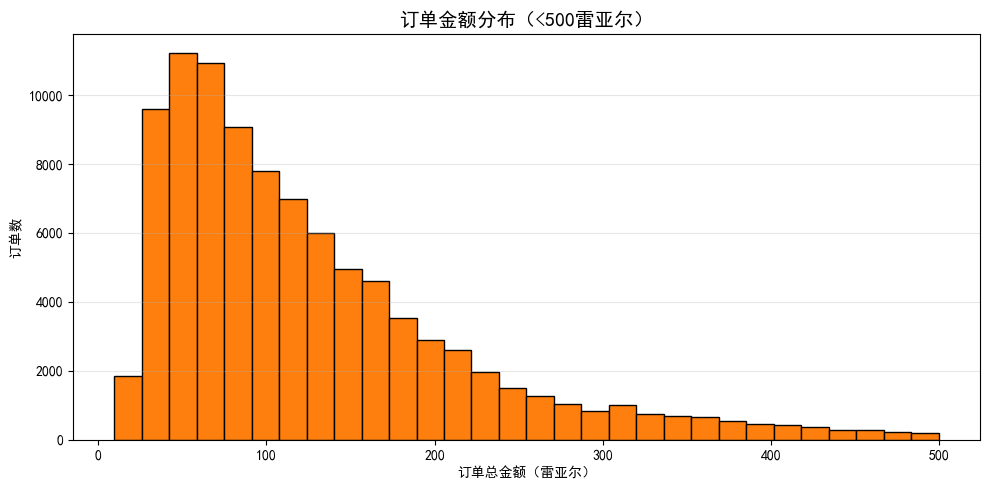

=== 订单金额统计 ===
平均订单金额：160.58 雷亚尔
中位数订单金额：105.29 雷亚尔


In [71]:
# 读取 order_items 表
items = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_order_items_dataset.csv")

# 1. 合并订单与商品数据
order_items = orders.merge(items, on="order_id", how="inner")

# 2. 统计单笔订单的商品数量
items_per_order = order_items.groupby("order_id")["order_item_id"].max()
print("=== 单笔订单商品数分布 ===")
print(items_per_order.value_counts().head(10))

# 3. 计算订单总金额（商品价格 + 运费）
order_items["total_amount"] = order_items["price"] + order_items["freight_value"]
order_total = order_items.groupby("order_id")["total_amount"].sum()

# 4. 画订单金额分布直方图
plt.figure(figsize=(10,5))
plt.hist(order_total[order_total < 500], bins=30, color="#ff7f0e", edgecolor="black")
plt.title("订单金额分布（<500雷亚尔）", fontsize=14)
plt.ylabel("订单数")
plt.xlabel("订单总金额（雷亚尔）")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("=== 订单金额统计 ===")
print(f"平均订单金额：{order_total.mean().round(2)} 雷亚尔")
print(f"中位数订单金额：{order_total.median().round(2)} 雷亚尔")

===== 1. 用户复购分析 =====
独立用户数：96,096
复购用户数：2,997
复购率：3.12%


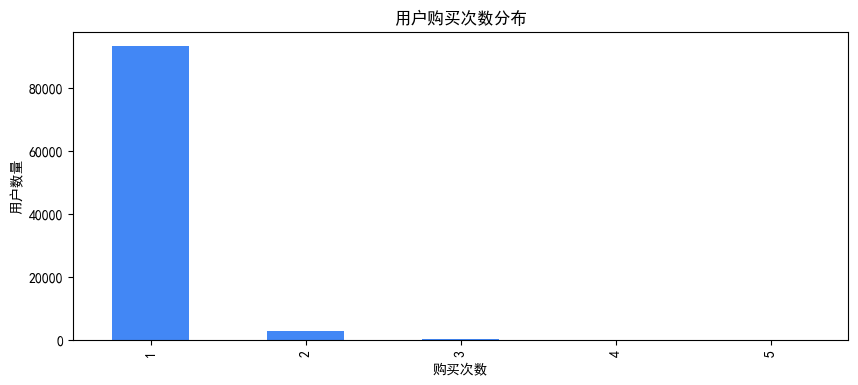


===== 2. GMV & 客单价 =====
总GMV：15,843,553.24 雷亚尔
总订单数：99,441
平均客单价：159.33 雷亚尔

===== 3. 商家发货准时率 =====
准时发货率：90.81%

===== 4. 运费占比（运费/商品价格） =====
平均运费占比：32.09%


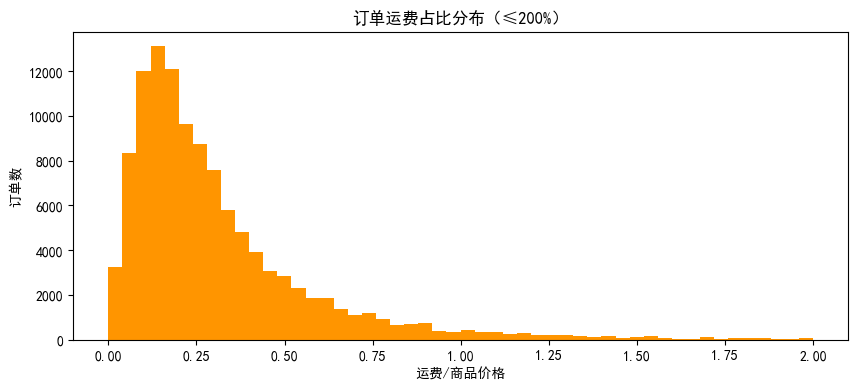

In [72]:
# ===================== 追加分析：用户复购 + GMV + 发货准时 + 运费占比 =====================

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取需要的表
orders = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_orders_dataset.csv")
items  = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_order_items_dataset.csv")
cust   = pd.read_csv("C:/Users/28098/Desktop/Olist/archive/olist_customers_dataset.csv")

# 合并数据
df = orders.merge(items, on="order_id", how="left")
df = df.merge(cust[["customer_id","customer_unique_id"]], on="customer_id", how="left")

# 时间格式转换
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["shipping_limit_date"] = pd.to_datetime(df["shipping_limit_date"])
df["order_delivered_carrier_date"] = pd.to_datetime(df["order_delivered_carrier_date"])

# ---------------------- 1. 独立用户数 & 复购率 ----------------------
user_order_cnt = df.groupby("customer_unique_id")["order_id"].nunique()
total_users = user_order_cnt.count()
repurchase_users = (user_order_cnt >= 2).sum()
repurchase_rate = repurchase_users / total_users

print("===== 1. 用户复购分析 =====")
print(f"独立用户数：{total_users:,}")
print(f"复购用户数：{repurchase_users:,}")
print(f"复购率：{repurchase_rate:.2%}")

plt.figure(figsize=(10,4))
user_order_cnt.value_counts().sort_index().head(5).plot(kind="bar", color="#4287f5")
plt.title("用户购买次数分布")
plt.xlabel("购买次数")
plt.ylabel("用户数量")
plt.show()

# ---------------------- 2. GMV & 客单价 ----------------------
df["gmv"] = df["price"] + df["freight_value"]
gmv_total = df["gmv"].sum()
order_cnt = df["order_id"].nunique()
avg_gmv = gmv_total / order_cnt

print("\n===== 2. GMV & 客单价 =====")
print(f"总GMV：{gmv_total:,.2f} 雷亚尔")
print(f"总订单数：{order_cnt:,}")
print(f"平均客单价：{avg_gmv:.2f} 雷亚尔")

# ---------------------- 3. 商家发货准时率 ----------------------
df["ship_delay"] = df["order_delivered_carrier_date"] > df["shipping_limit_date"]
on_time_rate = 1 - df["ship_delay"].mean()

print("\n===== 3. 商家发货准时率 =====")
print(f"准时发货率：{on_time_rate:.2%}")

# ---------------------- 4. 运费占比分析 ----------------------
df["freight_ratio"] = df["freight_value"] / df["price"]
avg_freight_ratio = df["freight_ratio"].mean()

print("\n===== 4. 运费占比（运费/商品价格） =====")
print(f"平均运费占比：{avg_freight_ratio:.2%}")

plt.figure(figsize=(10,4))
plt.hist(df[df["freight_ratio"] < 2]["freight_ratio"], bins=50, color="#ff9500")
plt.title("订单运费占比分布（≤200%）")
plt.xlabel("运费/商品价格")
plt.ylabel("订单数")
plt.show()

GMV 总额： 15843553.24
订单总数： 99441
付费用户数： 99441
客单价： 159.33


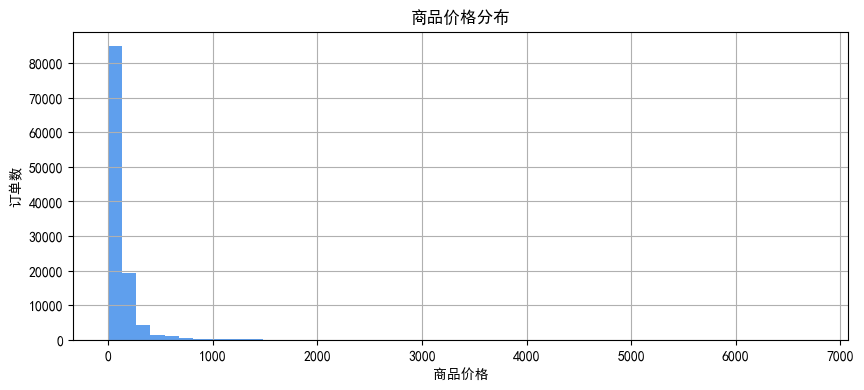

In [73]:
# --------------------
# 1. 四个核心指标计算（适配你的列名）
# --------------------
gmv = df['gmv'].sum()  # 用你已有的 gmv 列
order_cnt = df['order_id'].nunique()
customer_cnt = df['customer_id'].nunique()
aov = gmv / order_cnt

print('GMV 总额：', round(gmv, 2))
print('订单总数：', order_cnt)
print('付费用户数：', customer_cnt)
print('客单价：', round(aov, 2))

# --------------------
# 2. 商品价格分布直方图（替代支付金额）
# --------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
df['price'].dropna().hist(bins=50, color='#5f9fed')
plt.title('商品价格分布')
plt.xlabel('商品价格')
plt.ylabel('订单数')
plt.show()